# Gjeng
Vi kan definere en **gjeng** som et sett av noder som "henger sammen" men som henger løst sammen med resten.  Problemet er åpenbart: Hva betyr "henger sammen" og hva betyr "løst".

## Girvan-Newman

Vi kan bruke [Girvan-Newman](https://en.wikipedia.org/wiki/Girvan%E2%80%93Newman_algorithm) til å finne slike gjenger.  

Konseptet med en bronode er at mange korteste-sti passerer gjennom noden (som gjør den sentral sett i lys av informasjonsspredning).  Vi kan flytte fokus fra nodene til kantene, og sette vekt på kantene basert på hvor mange korteste-sti som går gjennom dem; en sti må naturligvis følge kanter like mye som noder.  Ved å fjerne kanter med høy vekt fragmenteres grafen, og gjengene står igjen.  De som først separeres ut er de som har bronoder som har få (men viktige) forbindelser til resten.

Kostnaden er $O(n^2k)$ hvor $n$ er antall noder og $k$ antall kanter.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
with open("lesmiserables-character-network/parsed_data/jean-complete-node.csv", "r") as fd:
    noder_rå = fd.readlines()
#
# Bort med første linje
noder_rå = noder_rå[1:]

# Formatet er 
# "TH","Thénardier","Thénardier, innkeeper in Montfermeil, aka Jondrette"\n
# Hent ut det vi trenger, og lag noder

G = nx.Graph()
for n in noder_rå:
    _s = n.split('"')
    G.add_node(_s[1], Navn=_s[3], Rolle=_s[5])
#
print(f"Antall noder i grafen: {G.number_of_nodes()}")

# Kantene
with open("lesmiserables-character-network/parsed_data/jean-complete-edge.csv", "r") as fd:
    kanter_rå = fd.readlines()
#
# Bort med første
kanter_rå = kanter_rå[1:]
print(f"Antall kanter: {len(kanter_rå)}")
#Formatet er 
# "MY","NP","Undirected","1","1.1.1" 
# hvor 1.1.1 er kapittelet hvor forbindelsen opptrer
for k in kanter_rå:
    _s = k.split(",")
    _ = G.add_edge(_s[0][1:3], _s[1][1:3])

Antall noder i grafen: 181
Antall kanter: 1589


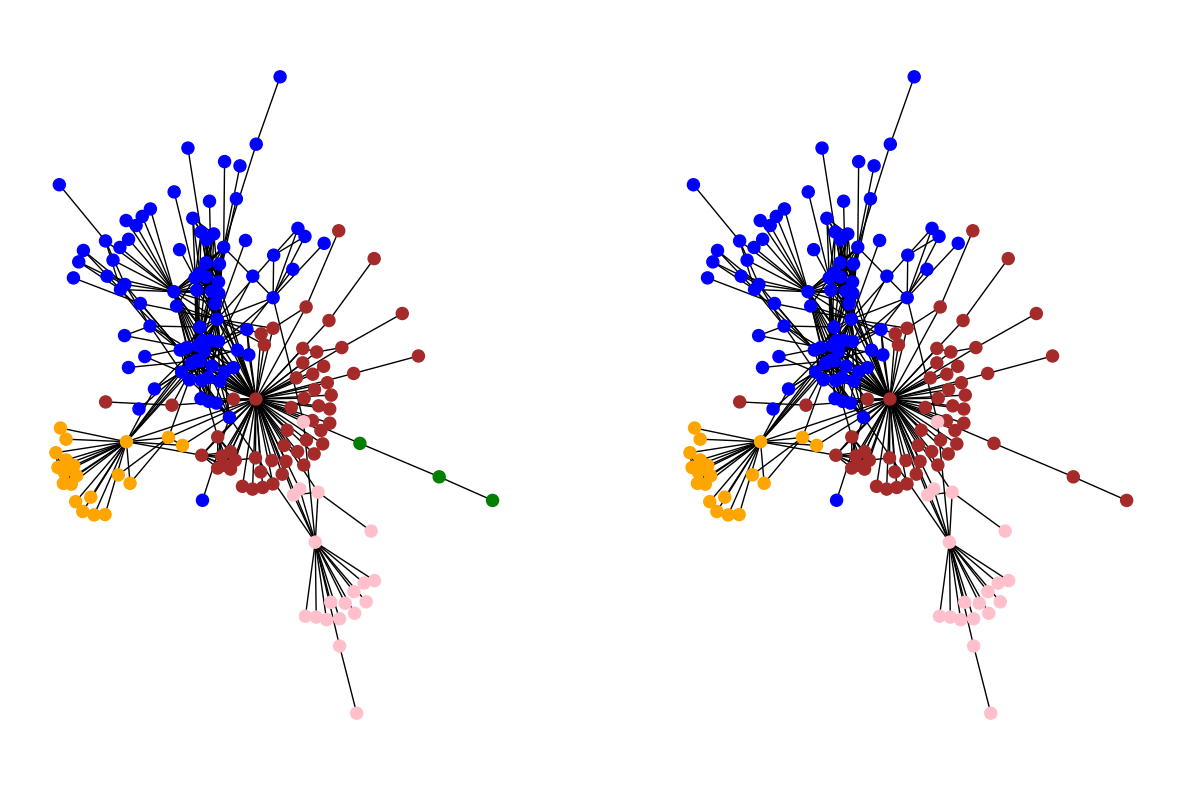

In [3]:
from networkx.algorithms.community import girvan_newman

# Denne deler grafen i stadig flere gjenger (itererer)
generator = girvan_newman(G)
første = next(generator)
andre = next(generator)
tredje = next(generator)
fjerde = next(generator)

# Håper det er færre gjenger enn det er farger
fargeliste = ["blue", "brown", "orange", "pink", "green", "gray", "red", "olive", "purple", "cyan"]

sett_id4 = {}
for snummer, s in enumerate(fjerde):
    for e in s:
        sett_id4[e] = snummer
    #
#
node_farge4 = []
for node in G:
    idx = sett_id4.get(node)
    node_farge4.append(fargeliste[idx])
#

sett_id3 = {}
for snummer, s in enumerate(tredje):
    for e in s:
        sett_id3[e] = snummer
    #
#
node_farge3 = []
for node in G:
    idx = sett_id3.get(node)
    node_farge3.append(fargeliste[idx])
#

# Tegne dem ved siden av hverandre
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 10))

pos = nx.spring_layout(G, seed=10) # Beste seed så langt
nx.draw(G, pos, ax=axes[0], with_labels=False, node_color=node_farge4, font_size=12, node_size=75)
nx.draw(G, pos, ax=axes[1], with_labels=False, node_color=node_farge3, font_size=12, node_size=75)
plt.show()

## Louvain

Vi kan se på en gjeng som noder som er tettere knyttet til hverandre enn til resten (de andre nodene).  Det vil si at om vi tar utgangspunkt i en tilfeldig graf (se nedenfor) så vil det være flere kanten i en gjeng enn vi forventer; tettheten er større.

Noder flyttes inn i grupper, og man ser om tettheten "omkring" går opp eller ned når noden flyttes fra en gjeng til en annen.  Man sitter igjen med den optimale delingen i gjenger.

Ulempen er at gjengene er gjensidig utelukkende; neppe representativ for virkeligheten.  Videre, når to nærliggende klikker slås sammen kan det godt tenkes at det er "godt" for den overordnede inndelingen, men at de to i utgangspunktet var tett knyttet går tapt.

kjøretiden er kun $O(n \log n)$ og kan derfor brukes også på svært store grafer.
Info [på Wikipedia](https://en.wikipedia.org/wiki/Louvain_method).

Fant 8 gjenger
Lederne er: ['XA', 'JA', 'MA', 'JU', 'CO', 'MY', 'FN', 'JV']


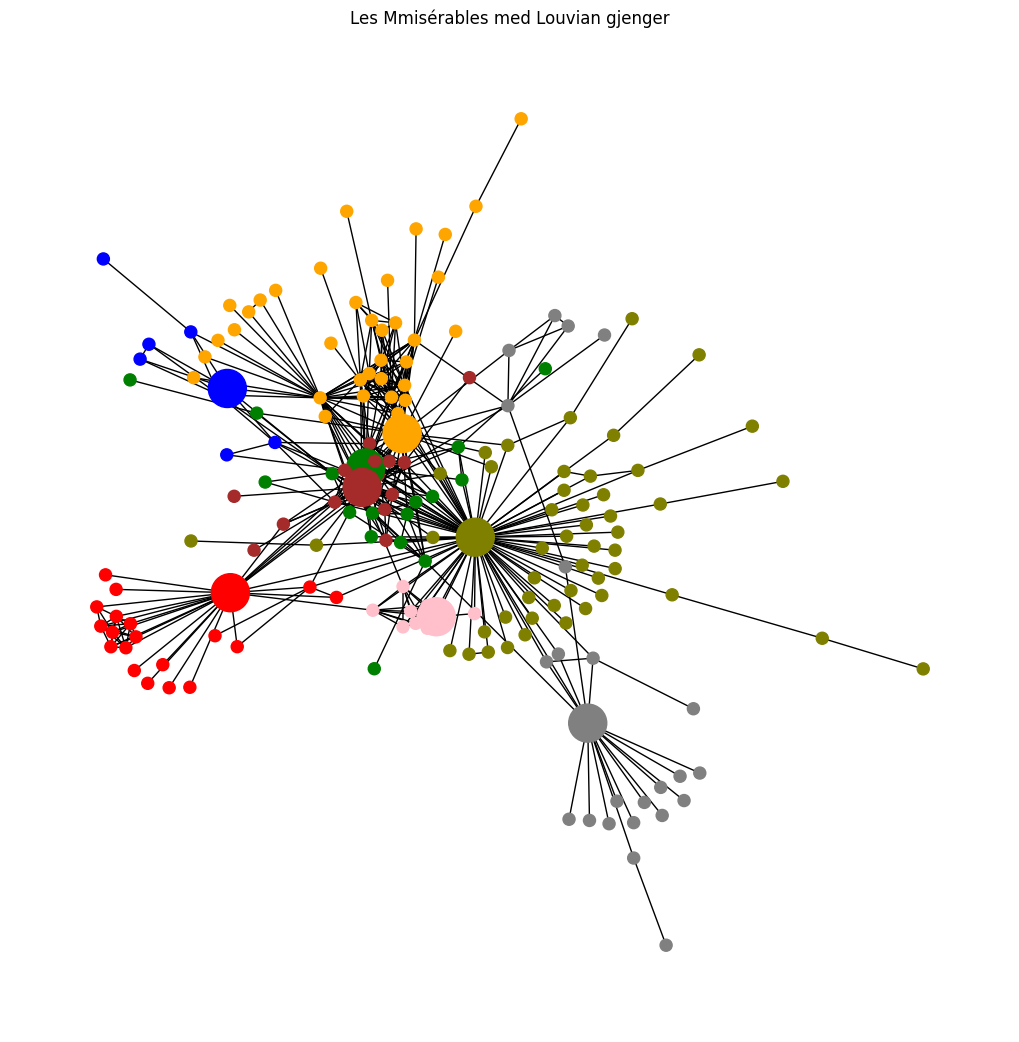

In [5]:
# Community detection with the Louvain Method
from networkx.algorithms.community import louvain_communities

# Calculate best partition for Louvain method
partitions = louvain_communities(G)
print(f"Fant {len(partitions)} gjenger")

# Finn de best forbindne i hver gjeng
ledere = []
for p in partitions:
    leder = max(p, key=lambda n:G.degree(n))
    ledere += [leder]
#
print(f"Lederne er: {ledere}")

# Håper det er færre gjenger enn det er farger
fargeliste = ["blue", "brown", "orange", "pink", "green", "gray", "red", "olive", "purple", "cyan"]
node_farge= []
størrelse = 75
node_størrelse = []
# Forutsetter at rekkefølgen er den samme hver gang
for node in G:
    # Hvilken partisjon er denne noden i?
    for idx, l in enumerate(partitions):
        if node in l:
            node_farge.append(fargeliste[idx])
            break
        #
    # Større noder for ledere
    if node in ledere:
        node_størrelse.append(størrelse* 10)
    else:
        node_størrelse.append(størrelse)
    #
#


# Vis frem
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G, seed=10)
nx.draw(G, pos, with_labels=False, node_color=node_farge, font_size=12, node_size=node_størrelse)
plt.title("Les Mmisérables med Louvian gjenger")
plt.show()

## Epost-datasettet


In [7]:
# La oss lage en graf
import networkx as nx
import gzip

EG = nx.DiGraph()
# husk at gzip påpner i 'b'
with gzip.open("data/email.edgelist.txt.gz", "rt") as fd:
    for linje in fd:
         link = linje.split()
         EG.add_edge(int(link[0]), int(link[1]))
    #
#
# Bort med eposter sendt til seg selv
EG.remove_edges_from(nx.selfloop_edges(EG))
isolerte = list(nx.isolates(EG)) # kan ikke bruke iteratorer direkte
EG.remove_nodes_from(isolerte)
print(f"Antall noder etter isolerte: {EG.number_of_nodes()}")

Antall noder etter isolerte: 57189


In [8]:
# Vi konverterer til til en graf som ikke er rettet; om du sender eller mottar en epost 
# har du likevel en relasjon.  Legg merke til at dette reduserer antall kanter!
UG = EG.to_undirected(EG)

In [9]:
# Tar noen sekunder
from networkx.algorithms.community import louvain_communities
# Louvain.  Burde brukt Leiden men da blir det mye GPU-greier
partition = louvain_communities(UG)

# Hvor mange fant vi
print(f"Vi fant {len(partition)} gjenger")
print(partition[0])

Vi fant 279 gjenger
{39936, 15365, 20490, 31755, 36875, 10, 45069, 15, 32783, 30737, 38930, 40979, 28692, 44053, 26646, 16407, 1047, 16402, 51219, 21531, 18460, 31756, 43031, 43032, 10273, 10275, 54309, 22567, 45098, 48, 39988, 18488, 26695, 35912, 22610, 24660, 1110, 26719, 42083, 51299, 22627, 11365, 47207, 24680, 36967, 10348, 45165, 42095, 50289, 47218, 45169, 50293, 25718, 47223, 121, 41082, 51322, 43131, 36986, 17534, 12416, 38017, 54402, 36994, 48266, 13458, 43155, 10388, 14485, 41110, 45207, 52376, 10393, 43156, 23709, 28830, 2213, 37035, 34988, 52395, 2221, 10416, 178, 32948, 21688, 40121, 44217, 40125, 18623, 56519, 25800, 21705, 22728, 21708, 34001, 12498, 28884, 10453, 27866, 12513, 11489, 39139, 2275, 53475, 27878, 13541, 34023, 37092, 15594, 17644, 23790, 3311, 27890, 54515, 36084, 10487, 51448, 39161, 19706, 51451, 11518, 26880, 25856, 40195, 55557, 30982, 51463, 15624, 46350, 53518, 22800, 48401, 53521, 33047, 39192, 24855, 45336, 56601, 37147, 17697, 41250, 28964, 3408

Se på den første gjengen

In [10]:
# Se på den første

from ipysigma import Sigma
import math

gjengen = UG.subgraph(partition[0])

log_degree = {}
for node, deg in gjengen.degree():
    log_degree[node] = math.log(deg + 1) 
#    
Sigma(
    gjengen, 
    node_size=log_degree,
    node_color=log_degree,
    node_color_gradient="Plasma",
    node_size_range=(1, 30),
    default_edge_type="curve"
)

Sigma(nx.Graph with 454 nodes and 529 edges)

In [12]:
from ipysigma import Sigma
import math

gjengen = UG.subgraph(partition[0]).copy()
# Identify nodes with degree 1
bladnoder = []
for n,d in gjengen.degree():
    if d < 3:
        bladnoder += [n]
    #
#

gjengen.remove_nodes_from(bladnoder)
log_degree = {}
for node, deg in gjengen.degree():
    log_degree[node] = math.log(deg + 1) 
#    
Sigma(
    gjengen, 
    node_size=log_degree,
    node_color=log_degree,
    node_color_gradient="Plasma",
    node_size_range=(1, 30),
    default_edge_type="curve"
)

Sigma(nx.Graph with 40 nodes and 76 edges)